# Sprint v8.3 -- Forensic Attribution Engine

**This is a forensic accounting layer on the v8.2 book. It explains
realized P&L; it does not predict future P&L, and it does not contain or
imply a security-selection capability -- every instrument here is an ETF
basket. Reconciliation to machine precision confirms the bookkeeping is
correct; it is not evidence the book is good.**

The book is frozen at its v8.2 closing values (`L=120`, `k_dead_zone=0.5`,
`band_pct=0.20`) -- this sprint does not change it. Seven decompositions:

1. per-instrument / per-asset-class P&L
2. long vs short P&L
3. directional (net exposure x market move) vs selection
4. factor regression: beta-explained vs residual -- the one genuinely
   empirical, non-tautological output of this sprint (decompositions
   1, 2, 3, 5, 6 are accounting identities by construction)
5. carry (dividend/distribution accrual) vs price change
6. gross vs net P&L via turnover/borrow cost
7. marginal contribution to portfolio vol by sleeve, ex-ante vs realized
   (reconciles to portfolio sigma, not P&L -- a different identity)

No monthly or lower-frequency factor enters any daily computation here
(House Rule 8) -- the He-Kelly-Manela intermediary capital factor is
omitted by design, not by data unavailability.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, _here)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from signals.etf_universe import load_universe_close, UNIVERSE, ASSET_CLASS
from signals.dividends import load_dividend_matrix
from risk.attribution import (
    build_v82_book, gross_pnl_series, per_instrument_pnl, per_asset_class_pnl,
    long_short_pnl, directional_selection_pnl, factor_returns, rolling_factor_regression,
    carry_price_pnl, gross_net_cost, mctr_by_sleeve, build_tidy_attribution,
    SLEEVES, RECONCILE_TOL, NOTIONAL_DEFAULT,
)

close = load_universe_close()
target, result = build_v82_book(close)
gross = gross_pnl_series(result)
print(f"universe: {len(UNIVERSE)} names, {close.index.min().date()} -> {close.index.max().date()}")
print(f"book: L=120, long_short=True, k_dead_zone=0.5, band_pct=0.20 (frozen at v8.2 closing values)")
print(f"total gross P&L over sample: ${gross.sum():,.0f}")
print(f"total net P&L over sample: ${result.daily_pnl.sum():,.0f}")

universe: 8 names, 2007-04-11 -> 2026-06-15
book: L=120, long_short=True, k_dead_zone=0.5, band_pct=0.20 (frozen at v8.2 closing values)
total gross P&L over sample: $880,154
total net P&L over sample: $812,038


## Decomposition 1 -- per-instrument and per-asset-class P&L (R1)

In [2]:
pnl_i = per_instrument_pnl(target, close)
pnl_class = per_asset_class_pnl(pnl_i)

r1 = (pnl_i.sum(axis=1, skipna=True) - gross).abs().max()
r1b = (pnl_class.sum(axis=1, skipna=True) - gross).abs().max()
print(f'R1 (per-instrument) max residual: {r1:.2e} (tolerance {RECONCILE_TOL*NOTIONAL_DEFAULT:.2e})')
print(f'R1 (per-asset-class) max residual: {r1b:.2e}')
print()
print('Cumulative P&L by asset class:')
print(pnl_class.sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

R1 (per-instrument) max residual: 1.46e-11 (tolerance 1.00e+00)
R1 (per-asset-class) max residual: 2.91e-11

Cumulative P&L by asset class:
commodity    $434,238
rates        $181,515
credit       $178,381
equity        $86,020
dtype: object


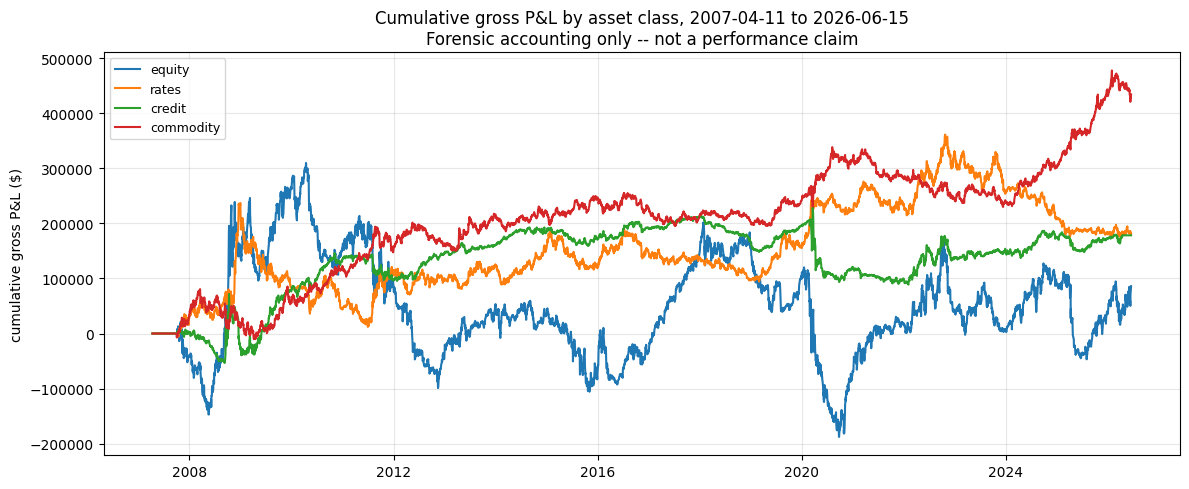

saved sprints/v8.3/plots/pnl_by_sleeve.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
cum = pnl_class.fillna(0).cumsum()
for sleeve in SLEEVES:
    ax.plot(cum.index, cum[sleeve], label=sleeve)
ax.set_title(f'Cumulative gross P&L by asset class, {close.index.min().date()} to {close.index.max().date()}\n'
             'Forensic accounting only -- not a performance claim')
ax.set_ylabel('cumulative gross P&L ($)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('sprints/v8.3/plots/pnl_by_sleeve.png', dpi=110)
plt.show()
print('saved sprints/v8.3/plots/pnl_by_sleeve.png')

## Decomposition 2 -- long vs short P&L (R2)

In [4]:
ls = long_short_pnl(target, pnl_i)
r2 = ((ls['pnl_long'] + ls['pnl_short']) - gross).abs().max()
print(f'R2 max residual: {r2:.2e}')
print(f"long bucket total: ${ls['pnl_long'].sum():,.0f}")
print(f"short bucket total: ${ls['pnl_short'].sum():,.0f}")

R2 max residual: 1.46e-11
long bucket total: $1,638,830
short bucket total: $-758,676


## Decomposition 3 -- directional vs selection (R3)

In [5]:
d3 = directional_selection_pnl(target, close, gross)
r3 = ((d3['directional'] + d3['selection']) - gross).abs().max()
print(f'R3 max residual: {r3:.2e}')
print(f"directional total: ${d3['directional'].sum():,.0f}")
print(f"selection total: ${d3['selection'].sum():,.0f}")
print('(selection is defined as gross_pnl - directional -- an accounting identity, not an independent measurement)')

R3 max residual: 7.28e-12
directional total: $1,138,143
selection total: $-257,989
(selection is defined as gross_pnl - directional -- an accounting identity, not an independent measurement)


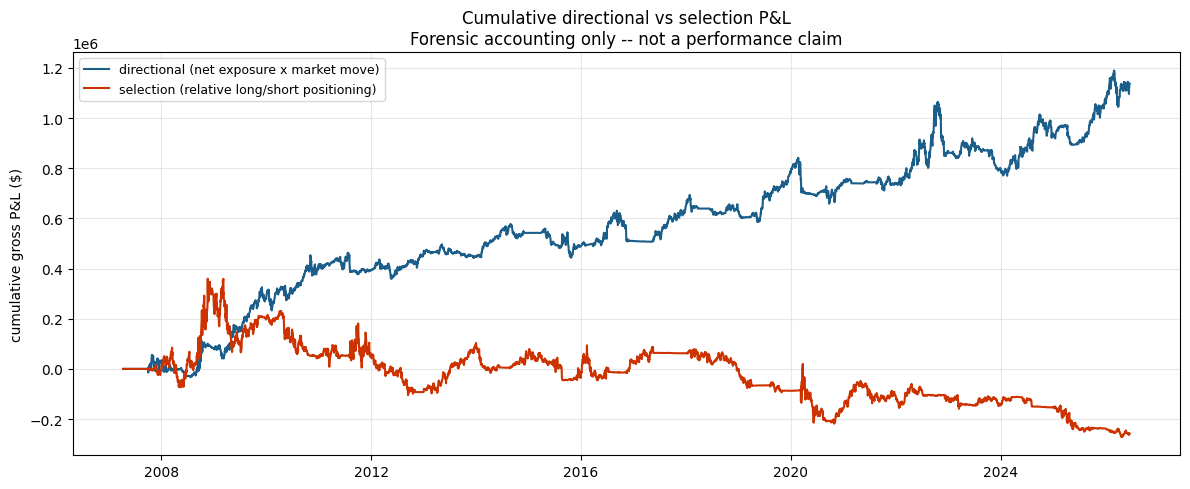

saved sprints/v8.3/plots/directional_vs_selection.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
cum3 = d3[['directional', 'selection']].fillna(0).cumsum()
ax.plot(cum3.index, cum3['directional'], label='directional (net exposure x market move)', color='#1b5e8a')
ax.plot(cum3.index, cum3['selection'], label='selection (relative long/short positioning)', color='#cc3300')
ax.set_title('Cumulative directional vs selection P&L\nForensic accounting only -- not a performance claim')
ax.set_ylabel('cumulative gross P&L ($)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('sprints/v8.3/plots/directional_vs_selection.png', dpi=110)
plt.show()
print('saved sprints/v8.3/plots/directional_vs_selection.png')

## Decomposition 4 -- factor regression (R4)

**The one genuinely empirical, non-tautological output of this sprint.**
Rolling 252-day OLS, refit daily, using only data through `t-1` to explain
day `t` (no future leakage -- tested explicitly in `tests/test_attribution.py`).
Four daily, exposure-matched factors (House Rule 8): equity (SPY), rates
(IEF), credit spread (HYG-IEF), gold (GLD). No monthly or lower-frequency
factor enters this regression -- the He-Kelly-Manela intermediary capital
factor is omitted by design, not fetched, not probed.

**The residual is exposure-timing, never security selection, never
alpha** (House Rule 7) -- there is no security-selection mechanism
anywhere in this programme; every instrument is an ETF basket.

In [7]:
factors = factor_returns(close)
book_ret = gross / NOTIONAL_DEFAULT
fr = rolling_factor_regression(book_ret, factors)

r4 = ((fr.beta_explained + fr.residual) - gross).abs().max()
print(f'R4 max residual: {r4:.2e}')
print()
print('Rolling R^2 summary (informational, not gated):')
print(fr.r_squared.dropna().describe())
print()
print(f"beta-explained total: ${fr.beta_explained.sum():,.0f}")
print(f"residual (exposure-timing, NOT selection, NOT alpha) total: ${fr.residual.sum():,.0f}")

R4 max residual: 7.28e-12

Rolling R^2 summary (informational, not gated):
count    4532.000000
mean        0.422703
std         0.208062
min         0.064141
25%         0.264453
50%         0.385964
75%         0.543120
max         0.928318
Name: r_squared, dtype: float64

beta-explained total: $-1,440,668
residual (exposure-timing, NOT selection, NOT alpha) total: $2,295,741


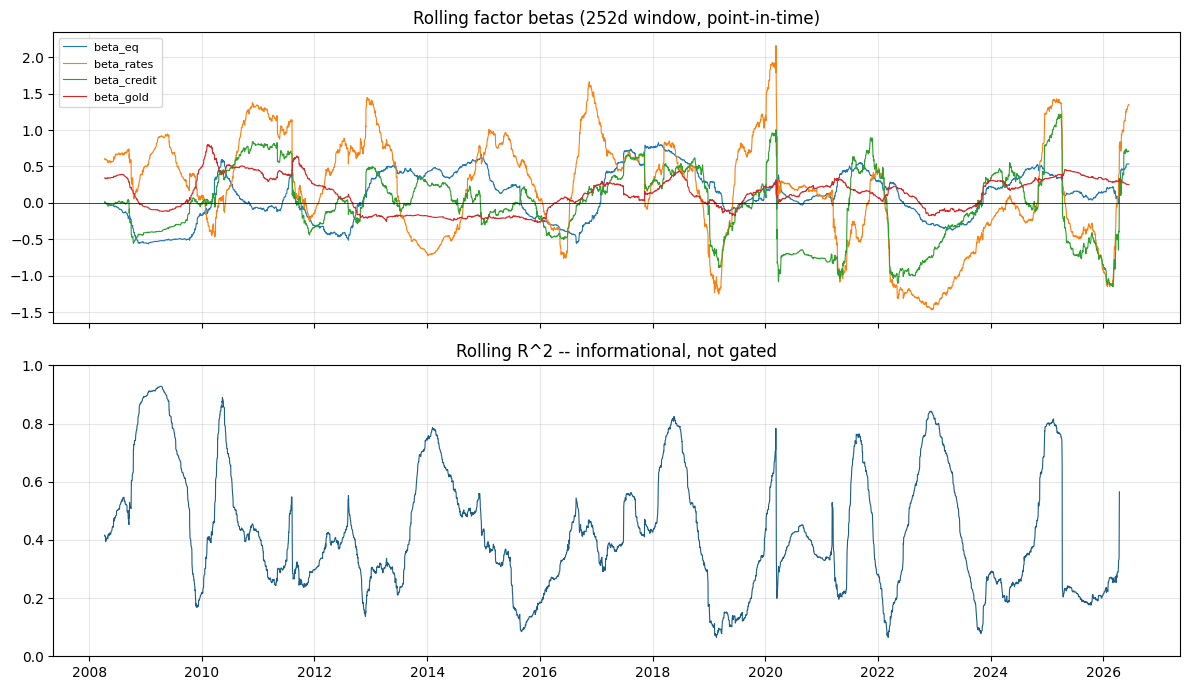

saved sprints/v8.3/plots/factor_betas.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
betas_plot = fr.betas.dropna()
ax = axes[0]
for col in ['beta_eq', 'beta_rates', 'beta_credit', 'beta_gold']:
    ax.plot(betas_plot.index, betas_plot[col], label=col, lw=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Rolling factor betas (252d window, point-in-time)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(fr.r_squared.dropna().index, fr.r_squared.dropna().values, color='#1b5e8a', lw=0.8)
ax2.set_title('Rolling R^2 -- informational, not gated')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('sprints/v8.3/plots/factor_betas.png', dpi=110)
plt.show()
print('saved sprints/v8.3/plots/factor_betas.png')

## Decomposition 5 -- carry vs price change (R5)

In [9]:
dividends = load_dividend_matrix(UNIVERSE, close.index)
cp = carry_price_pnl(target, close, dividends, pnl_i)

residuals = []
for ticker in UNIVERSE:
    recombined = cp[f'carry_{ticker}'] + cp[f'price_change_{ticker}']
    residuals.append((recombined - pnl_i[ticker]).abs().max())
print(f'R5 max residual across all tickers: {max(residuals):.2e}')
print()
carry_cols = [f'carry_{t}' for t in UNIVERSE]
total_carry = cp[carry_cols].sum().sum()
print(f'total carry: ${total_carry:,.0f}  ({total_carry/gross.sum():.1%} of total gross P&L)')
print(f'total price change: ${gross.sum() - total_carry:,.0f}')
print()
print('carry by ticker (GLD is exactly zero -- physical gold pays no income, expected, not a gap):')
print(cp[carry_cols].sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))

R5 max residual across all tickers: 9.09e-13

total carry: $612,274  (69.6% of total gross P&L)
total price change: $267,880

carry by ticker (GLD is exactly zero -- physical gold pays no income, expected, not a gap):
carry_HYG    $266,429
carry_LQD    $123,602
carry_EFA     $63,098
carry_IEF     $62,795
carry_SPY     $40,494
carry_TLT     $31,530
carry_EEM     $24,325
carry_GLD          $0
dtype: object


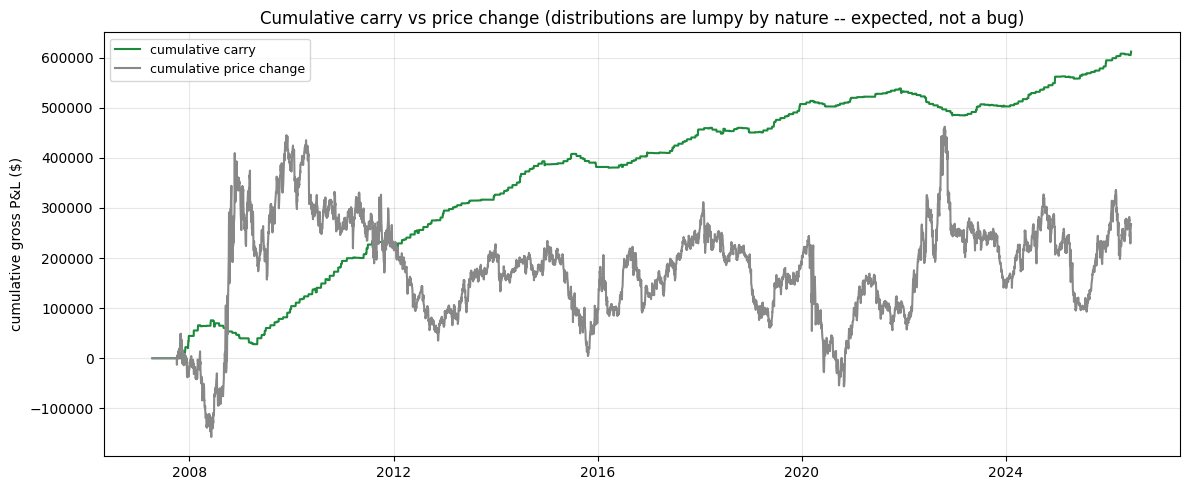

saved sprints/v8.3/plots/carry_vs_price.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
total_carry_series = cp[carry_cols].sum(axis=1)
ax.plot(total_carry_series.index, total_carry_series.cumsum(), label='cumulative carry', color='#1b8a3a')
price_change_cols = [f'price_change_{t}' for t in UNIVERSE]
total_price_series = cp[price_change_cols].sum(axis=1)
ax.plot(total_price_series.index, total_price_series.cumsum(), label='cumulative price change', color='#888888')
ax.set_title('Cumulative carry vs price change (distributions are lumpy by nature -- expected, not a bug)')
ax.set_ylabel('cumulative gross P&L ($)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('sprints/v8.3/plots/carry_vs_price.png', dpi=110)
plt.show()
print('saved sprints/v8.3/plots/carry_vs_price.png')

## Decomposition 6 -- gross vs net, turnover cost in bps (R6)

In [11]:
gnc = gross_net_cost(result)
r6 = ((gnc['net_pnl'] + gnc['turnover_cost'] + gnc['borrow_cost']) - gnc['gross_pnl']).abs().max()
print(f'R6 max residual: {r6:.2e} (exact by construction -- this re-exposes run_multi_asset, not a recomputation)')
print()
print(f"total turnover cost: ${gnc['turnover_cost'].sum():,.0f} ({gnc['turnover_cost_bps'].mean():.2f} bps/day average)")
print(f"total borrow cost: ${gnc['borrow_cost'].sum():,.0f} ({gnc['borrow_cost_bps'].mean():.2f} bps/day average)")

R6 max residual: 0.00e+00 (exact by construction -- this re-exposes run_multi_asset, not a recomputation)

total turnover cost: $20,989 (0.04 bps/day average)
total borrow cost: $47,127 (0.10 bps/day average)


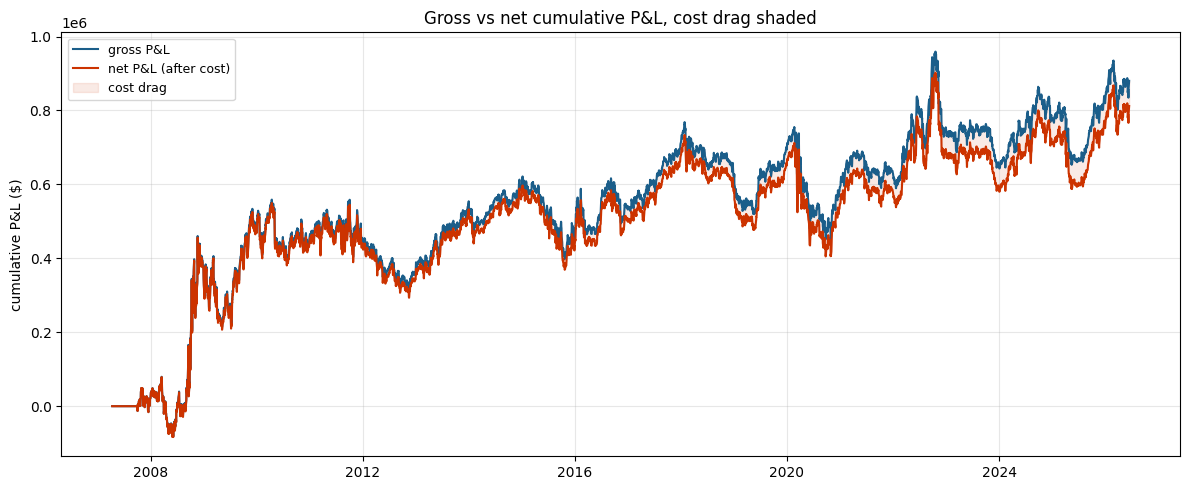

saved sprints/v8.3/plots/gross_vs_net.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gnc.index, gnc['gross_pnl'].cumsum(), label='gross P&L', color='#1b5e8a')
ax.plot(gnc.index, gnc['net_pnl'].cumsum(), label='net P&L (after cost)', color='#cc3300')
ax.fill_between(gnc.index, gnc['net_pnl'].cumsum(), gnc['gross_pnl'].cumsum(), color='#cc3300', alpha=0.1, label='cost drag')
ax.set_title('Gross vs net cumulative P&L, cost drag shaded')
ax.set_ylabel('cumulative P&L ($)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('sprints/v8.3/plots/gross_vs_net.png', dpi=110)
plt.show()
print('saved sprints/v8.3/plots/gross_vs_net.png')

## Decomposition 7 -- marginal contribution to portfolio vol, by sleeve (R7)

**Reconciles to portfolio sigma, not to P&L -- a different identity from
Decompositions 1-6** (Euler decomposition: sum of sleeve MCTRs = portfolio
vol, exactly). Realized uses a window that includes day `t` itself -- a
deliberate, stated use of hindsight appropriate for a forensic, after-the-
fact risk report. It is not a trading input and does not violate this
sprint's no-look-ahead rule, which governs the P&L attribution and the
factor betas, not this retrospective diagnostic.

In [13]:
mctr = mctr_by_sleeve(target, close)
sleeve_cols = [f'mctr_{s}' for s in SLEEVES]
mctr['sum_check'] = mctr[sleeve_cols].sum(axis=1)
r7 = (mctr['sum_check'] - mctr['sigma_portfolio']).abs().max()
print(f'R7 max residual: {r7:.2e} (reconciles to sigma_portfolio, not P&L)')
print()
print('Mean MCTR by sleeve, ex-ante vs realized:')
print(mctr.groupby('mode')[sleeve_cols].mean())

R7 max residual: 1.39e-17 (reconciles to sigma_portfolio, not P&L)

Mean MCTR by sleeve, ex-ante vs realized:
          mctr_equity  mctr_rates  mctr_credit  mctr_commodity
mode                                                          
ex_ante      0.005137    0.001716     0.001221        0.001047
realized     0.005139    0.001718     0.001221        0.001050


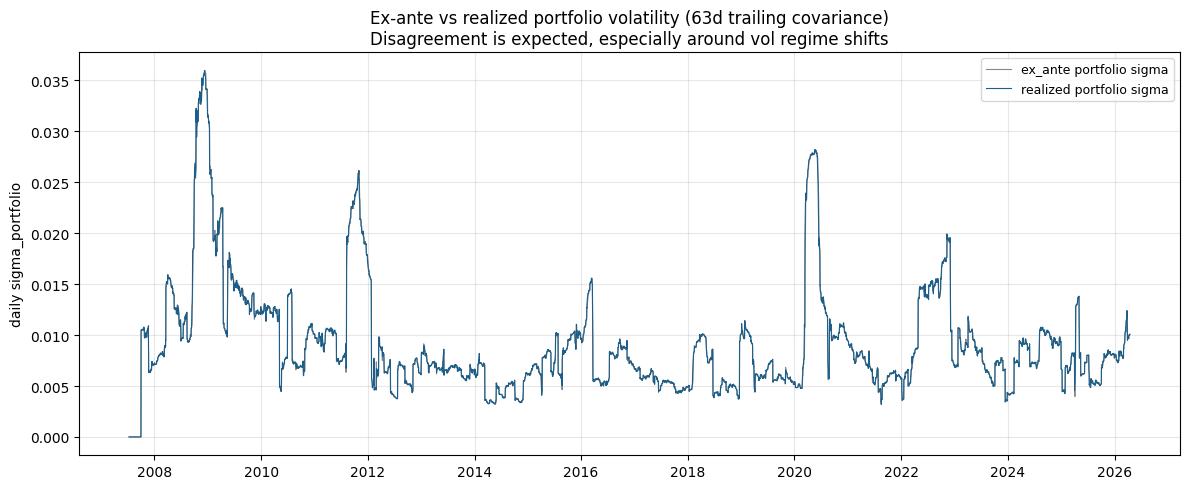

saved sprints/v8.3/plots/mctr_by_sleeve.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
for mode, color in [('ex_ante', '#888888'), ('realized', '#1b5e8a')]:
    sub = mctr[mctr['mode'] == mode].set_index('date')
    ax.plot(sub.index, sub['sigma_portfolio'], label=f'{mode} portfolio sigma', color=color, lw=0.8)
ax.set_title('Ex-ante vs realized portfolio volatility (63d trailing covariance)\n'
             'Disagreement is expected, especially around vol regime shifts')
ax.set_ylabel('daily sigma_portfolio')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('sprints/v8.3/plots/mctr_by_sleeve.png', dpi=110)
plt.show()
print('saved sprints/v8.3/plots/mctr_by_sleeve.png')

## Tidy daily attribution frame (dashboard-ready)

In [15]:
tidy = build_tidy_attribution(target, close, result, dividends, fr, d3)
print(f'tidy attribution frame: {tidy.shape}')
print(tidy.columns.tolist())
tidy.to_parquet('data/processed/attribution.parquet')
mctr.to_parquet('data/processed/attribution_mctr_by_sleeve.parquet')
print('saved data/processed/attribution.parquet and data/processed/attribution_mctr_by_sleeve.parquet')

tidy attribution frame: (38608, 17)
['date', 'ticker', 'asset_class', 'weight', 'pnl', 'carry', 'price_change', 'gross_pnl', 'net_pnl', 'turnover_cost', 'borrow_cost', 'directional', 'selection', 'net_exposure', 'beta_explained', 'residual', 'r_squared']
saved data/processed/attribution.parquet and data/processed/attribution_mctr_by_sleeve.parquet


## Sanity baseline -- hand-verify 2 known dates (T9)

In [16]:
import numpy as np

def hand_verify(d):
    row = tidy[tidy['date'] == pd.Timestamp(d)]
    if row.empty:
        print(f'{d}: not in sample')
        return
    hand_total = row['pnl'].sum()
    pipeline_total = gross.loc[pd.Timestamp(d)]
    print(f'{d}: hand-summed per-instrument pnl = {hand_total:,.2f}, pipeline gross_pnl = {pipeline_total:,.2f}, '
          f'diff = {abs(hand_total - pipeline_total):.2e}')

# a high-turnover-looking date and a date with a known HYG distribution
hand_verify(gross.abs().sort_values(ascending=False).index[5])
hyg_div_dates = dividends[dividends['HYG'] > 0].index
hand_verify(hyg_div_dates[len(hyg_div_dates)//2])

2008-10-15 00:00:00: hand-summed per-instrument pnl = 75,236.25, pipeline gross_pnl = 75,236.25, diff = 0.00e+00
2016-12-01 00:00:00: hand-summed per-instrument pnl = -309.23, pipeline gross_pnl = -309.23, diff = 1.14e-13


## Guardrail (S3, verbatim)

"This is a forensic accounting layer on the v8.2 book. It explains
realized P&L; it does not predict future P&L, and it does not contain or
imply a security-selection capability -- every instrument here is an ETF
basket. Reconciliation to machine precision confirms the bookkeeping is
correct; it is not evidence the book is good."

In [17]:
print('[notebook clean]')

[notebook clean]
